# CLIP From Scratch
## Implementing Radford et al. (2021): "Learning Transferable Visual Models From Natural Language Supervision"
---

## What this notebook is

Every component of CLIP implemented from scratch in pure PyTorch.  
No `import clip`. No HuggingFace. No copied code.  
Only the equations from Radford et al. 2021, translated into code.

## The three things CLIP does (from the paper)

1. **Image Encoder** — a Vision Transformer (ViT) that maps an image to a vector
2. **Text Encoder** — a Transformer that maps a text string to a vector  
3. **Contrastive Training** — pushes matching image-text pairs together, non-matching apart

## Paper reference
Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S., ... & Sutskever, I. (2021).  
*Learning transferable visual models from natural language supervision.*  
International Conference on Machine Learning (ICML).

---

## Structure
- **Section 1:** The core mathematical idea — contrastive learning
- **Section 2:** Multi-Head Self-Attention (shared by both encoders)
- **Section 3:** Vision Transformer (ViT) — the image encoder
- **Section 4:** Text Transformer — the text encoder
- **Section 5:** CLIP model — combining both encoders
- **Section 6:** Contrastive loss — the training objective
- **Section 7:** Training loop on synthetic data
- **Section 8:** Zero-shot inference — the key application
- **Section 9:** Visualisation of the learned embedding space

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
# Pure PyTorch only. No clip library. No transformers library.

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
import math
import warnings
warnings.filterwarnings('ignore')

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)
print('All imports done. Building CLIP from scratch.')

Device: cuda
GPU: Tesla T4
All imports done. Building CLIP from scratch.


---
# Section 1: The Core Mathematical Idea

## What Radford et al. proposed

Given a batch of $N$ (image, text) pairs, CLIP trains two encoders such that:
- The $N$ **correct** pairs have **high** cosine similarity
- The $N^2 - N$ **incorrect** pairs have **low** cosine similarity

## The similarity matrix (Figure 3 in the paper)

For a batch of $N$ pairs:
$$I_f = f(\text{images}) \in \mathbb{R}^{N \times d_e}  \quad \text{(image embeddings)}$$
$$T_f = g(\text{texts})  \in \mathbb{R}^{N \times d_e}  \quad \text{(text embeddings)}$$

Normalise both to unit length, then compute:
$$S = I_f \cdot T_f^T \cdot \exp(t) \in \mathbb{R}^{N \times N}$$

where $t$ is a **learned temperature** parameter (log scale).

$S_{ij}$ = similarity between image $i$ and text $j$.  
The diagonal ($S_{ii}$) should be high (correct pairs).  
Off-diagonal ($S_{ij}, i \neq j$) should be low (incorrect pairs).

## The contrastive loss (Equation 1 in the paper)

Treat each row of $S$ as a classification problem (which text matches image $i$?):  
$$L_\text{image} = \frac{1}{N} \sum_{i=1}^N \text{CrossEntropy}(S_{i,:},\, i)$$

Treat each column of $S$ as a classification problem (which image matches text $j$?):  
$$L_\text{text} = \frac{1}{N} \sum_{j=1}^N \text{CrossEntropy}(S_{:,j},\, j)$$

Total loss:
$$L_\text{CLIP} = \frac{L_\text{image} + L_\text{text}}{2}$$

The label for every row and every column is simply the **index** $i$ (the diagonal).  
This is an elegant symmetric loss — both encoders are trained simultaneously.

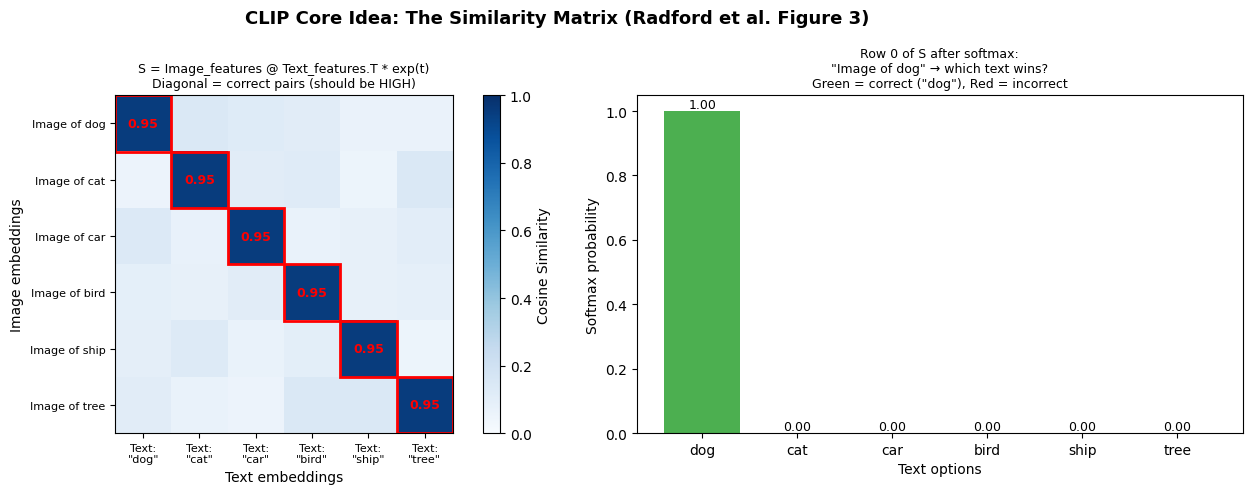

CrossEntropy on each row = loss for image encoder
CrossEntropy on each col = loss for text encoder
Total CLIP loss = (L_image + L_text) / 2


In [3]:
# ── Visualise the similarity matrix concept ────────────────────────────────
# This is Figure 3 from Radford et al. — the core idea visualised

N = 6  # batch size for illustration

# Simulate a perfect similarity matrix (diagonal high, off-diagonal low)
S_ideal = np.full((N, N), 0.1)   # off-diagonal: low similarity
np.fill_diagonal(S_ideal, 0.95)  # diagonal: high similarity (correct pairs)
S_ideal += np.random.uniform(-0.05, 0.05, (N, N))  # add noise for realism
np.fill_diagonal(S_ideal, 0.95)

labels = ['dog', 'cat', 'car', 'bird', 'ship', 'tree']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CLIP Core Idea: The Similarity Matrix (Radford et al. Figure 3)',
             fontsize=13, fontweight='bold')

# Left: similarity matrix heatmap
ax = axes[0]
im = ax.imshow(S_ideal, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels([f'Text:\n"{l}"' for l in labels], fontsize=8)
ax.set_yticklabels([f'Image of {l}' for l in labels], fontsize=8)
ax.set_xlabel('Text embeddings', fontsize=10)
ax.set_ylabel('Image embeddings', fontsize=10)
ax.set_title('S = Image_features @ Text_features.T * exp(t)\nDiagonal = correct pairs (should be HIGH)', fontsize=9)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
# Highlight diagonal
for i in range(N):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                               fill=False, edgecolor='red', linewidth=2))
    ax.text(i, i, f'{S_ideal[i,i]:.2f}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='red')

# Right: what the loss does
ax = axes[1]
# Show row 0 as a softmax classification
row = S_ideal[0]
softmax_row = np.exp(row * 10) / np.exp(row * 10).sum()  # exaggerate for clarity
colors = ['#4CAF50' if i == 0 else '#F44336' for i in range(N)]
bars = ax.bar(labels, softmax_row, color=colors)
ax.set_title('Row 0 of S after softmax:\n"Image of dog" → which text wins?\n'
             'Green = correct ("dog"), Red = incorrect', fontsize=9)
ax.set_ylabel('Softmax probability')
ax.set_xlabel('Text options')
for bar, val in zip(bars, softmax_row):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('clip_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('CrossEntropy on each row = loss for image encoder')
print('CrossEntropy on each col = loss for text encoder')
print('Total CLIP loss = (L_image + L_text) / 2')

---
# Section 2: Multi-Head Self-Attention

Both the image encoder (ViT) and text encoder (Transformer) use the same attention mechanism.  
We implement it once and reuse it.

## The attention equations (Vaswani et al. 2017, used in CLIP)

Given input sequence $X \in \mathbb{R}^{n \times d}$:

**Compute Query, Key, Value:**
$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

**Scaled dot-product attention:**
$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ scaling prevents the dot products from growing too large (which would push softmax into saturation).

**Multi-head:** run $h$ attention heads in parallel, concatenate, project:
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W_O$$

## Transformer block
Each Transformer block applies:
1. LayerNorm → Multi-Head Attention → residual add
2. LayerNorm → MLP (Feed-Forward) → residual add

$$x = x + \text{MHSA}(\text{LN}(x))$$
$$x = x + \text{MLP}(\text{LN}(x))$$

In [4]:
# ── Multi-Head Self-Attention ──────────────────────────────────────────────

class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention from Vaswani et al. 2017.
    Used identically in both ViT (image) and Transformer (text) in CLIP.

    Arguments:
        d_model  -- embedding dimension (e.g. 512)
        n_heads  -- number of attention heads (e.g. 8)
        dropout  -- dropout probability

    Each head operates on dimension d_head = d_model // n_heads.
    All heads run in parallel then concatenated.
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0, 'n_heads must divide d_model evenly'

        self.d_model  = d_model
        self.n_heads  = n_heads
        self.d_head   = d_model // n_heads   # dimension per head
        self.scale    = self.d_head ** -0.5  # 1/sqrt(d_k) scaling factor

        # Single linear layer projects input to Q, K, V simultaneously
        # Output dim = 3 * d_model (for Q, K, V stacked)
        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)

        # Output projection after concatenating all heads
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        self.dropout  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor = None) -> torch.Tensor:
        """
        Arguments:
            x    -- input tensor of shape (batch, seq_len, d_model)
            mask -- optional causal mask for text (batch, seq_len, seq_len)

        Returns:
            out  -- shape (batch, seq_len, d_model)
        """
        B, N, D = x.shape   # batch, sequence length, embedding dim

        # ── Step 1: Compute Q, K, V ───────────────────────────────────────
        # Project x → (B, N, 3*D), then split into Q, K, V
        qkv = self.qkv_proj(x)                    # (B, N, 3*D)
        qkv = qkv.reshape(B, N, 3, self.n_heads, self.d_head)
        qkv = qkv.permute(2, 0, 3, 1, 4)         # (3, B, n_heads, N, d_head)
        Q, K, V = qkv[0], qkv[1], qkv[2]         # each: (B, n_heads, N, d_head)

        # ── Step 2: Scaled dot-product attention ──────────────────────────
        # attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
        attn = (Q @ K.transpose(-2, -1)) * self.scale  # (B, n_heads, N, N)

        # Apply mask if provided (for causal/autoregressive text generation)
        if mask is not None:
            # mask=True means BLOCK attention to that position
            attn = attn.masked_fill(mask, float('-inf'))

        attn = F.softmax(attn, dim=-1)             # (B, n_heads, N, N)
        attn = self.dropout(attn)

        # ── Step 3: Weighted sum of values ────────────────────────────────
        out = attn @ V                             # (B, n_heads, N, d_head)

        # ── Step 4: Concatenate heads and project ─────────────────────────
        out = out.transpose(1, 2)                  # (B, N, n_heads, d_head)
        out = out.reshape(B, N, D)                 # (B, N, d_model) — concatenated
        out = self.out_proj(out)                   # (B, N, d_model) — projected

        return out


# Quick shape test
mhsa = MultiHeadSelfAttention(d_model=512, n_heads=8)
x_test = torch.randn(4, 16, 512)   # batch=4, seq=16, dim=512
out_test = mhsa(x_test)
print(f'MHSA input  shape: {x_test.shape}')
print(f'MHSA output shape: {out_test.shape}   (same shape — correct!)')
print(f'Scale factor 1/sqrt(d_head) = 1/sqrt(64) = {mhsa.scale:.4f}')

MHSA input  shape: torch.Size([4, 16, 512])
MHSA output shape: torch.Size([4, 16, 512])   (same shape — correct!)
Scale factor 1/sqrt(d_head) = 1/sqrt(64) = 0.1250


In [5]:
# ── Transformer Block ──────────────────────────────────────────────────────

class TransformerBlock(nn.Module):
    """
    One Transformer block as used in CLIP.
    Pre-norm design (LayerNorm BEFORE attention/MLP, not after).
    Radford et al. use pre-norm following GPT-2 convention.

    Forward:
        x = x + MHSA(LN(x))          residual connection 1
        x = x + MLP(LN(x))           residual connection 2

    MLP: d_model → 4*d_model → GELU → d_model
    (GELU activation used in CLIP, not ReLU)
    """
    def __init__(self, d_model: int, n_heads: int,
                 mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()

        self.ln1  = nn.LayerNorm(d_model)   # LayerNorm before attention
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)

        self.ln2  = nn.LayerNorm(d_model)   # LayerNorm before MLP
        d_mlp = int(d_model * mlp_ratio)    # hidden dim of MLP = 4 * d_model
        self.mlp  = nn.Sequential(
            nn.Linear(d_model, d_mlp),
            nn.GELU(),                       # GELU not ReLU (per CLIP paper)
            nn.Dropout(dropout),
            nn.Linear(d_mlp, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor = None) -> torch.Tensor:
        # Residual connection 1: attention
        x = x + self.attn(self.ln1(x), mask)
        # Residual connection 2: MLP
        x = x + self.mlp(self.ln2(x))
        return x


# Test
block = TransformerBlock(d_model=512, n_heads=8)
out_block = block(x_test)
print(f'TransformerBlock input:  {x_test.shape}')
print(f'TransformerBlock output: {out_block.shape}   (same — residual connections preserve shape)')

params_block = sum(p.numel() for p in block.parameters())
print(f'Parameters in one block: {params_block:,}')

TransformerBlock input:  torch.Size([4, 16, 512])
TransformerBlock output: torch.Size([4, 16, 512])   (same — residual connections preserve shape)
Parameters in one block: 3,150,336


---
# Section 3: Vision Transformer (ViT) — Image Encoder

## How ViT works (Dosovitskiy et al. 2020, used in CLIP)

1. **Patch embedding:** Split image into fixed-size patches, linearly embed each patch
2. **CLS token:** Prepend a learnable classification token
3. **Position embedding:** Add learnable position embeddings
4. **Transformer layers:** Run through $L$ transformer blocks
5. **Projection:** Take CLS token output, project to embedding space $d_e$

## Equations

For image $I \in \mathbb{R}^{H \times W \times C}$, patch size $P$:

Number of patches: $n = HW / P^2$

Patch embedding:
$$x_p^i = \text{Linear}(\text{patch}_i) \in \mathbb{R}^{d_\text{model}}$$

Input sequence with CLS token:
$$z_0 = [x_\text{cls};\; x_p^1;\; x_p^2;\; \ldots;\; x_p^n] + E_\text{pos}$$

After $L$ Transformer blocks:
$$z_L = \text{Transformer}(z_0)$$

Image embedding (take CLS token, apply LayerNorm and linear projection):
$$I_f = W_I \cdot \text{LN}(z_L^{[0]}) \in \mathbb{R}^{d_e}$$

In [6]:
# ── Vision Transformer (ViT) — Image Encoder ──────────────────────────────

class VisionTransformer(nn.Module):
    """
    Vision Transformer image encoder as used in CLIP.
    Based on Dosovitskiy et al. 2020 with CLIP-specific modifications.

    Pipeline:
        image (B,C,H,W)
          → patch embed (B, n_patches, d_model)
          → prepend CLS token (B, n_patches+1, d_model)
          → add position embed
          → L × TransformerBlock
          → LayerNorm
          → take CLS token output
          → linear project to d_embed
          → L2 normalise

    Arguments:
        image_size  -- input image size (square assumed)
        patch_size  -- size of each patch (e.g. 16 → 16×16 patches)
        in_channels -- image channels (3 for RGB)
        d_model     -- internal transformer dimension
        n_layers    -- number of transformer blocks
        n_heads     -- attention heads per block
        d_embed     -- output embedding dimension (shared with text encoder)
        dropout     -- dropout rate
    """
    def __init__(
        self,
        image_size:  int = 224,
        patch_size:  int = 16,
        in_channels: int = 3,
        d_model:     int = 512,
        n_layers:    int = 6,
        n_heads:     int = 8,
        d_embed:     int = 256,
        dropout:     float = 0.0
    ):
        super().__init__()
        assert image_size % patch_size == 0, 'Image size must be divisible by patch size'

        self.patch_size = patch_size
        self.d_model    = d_model
        n_patches = (image_size // patch_size) ** 2   # number of patches

        # ── Patch Embedding ───────────────────────────────────────────────
        # Equivalent to: reshape image into patches, then linear embed
        # Conv2d with kernel=patch_size, stride=patch_size does this efficiently
        self.patch_embed = nn.Conv2d(
            in_channels, d_model,
            kernel_size=patch_size, stride=patch_size
        )

        # ── CLS Token ─────────────────────────────────────────────────────
        # Learnable token prepended to patch sequence
        # Output of this token after transformer = image representation
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # ── Positional Embeddings ─────────────────────────────────────────
        # +1 for the CLS token position
        self.pos_embed = nn.Parameter(
            torch.randn(1, n_patches + 1, d_model) * 0.02
        )

        self.dropout   = nn.Dropout(dropout)

        # ── Transformer Blocks ────────────────────────────────────────────
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])

        # ── Output LayerNorm ──────────────────────────────────────────────
        self.ln_post = nn.LayerNorm(d_model)

        # ── Projection to shared embedding space ──────────────────────────
        # Projects d_model → d_embed (shared dimension with text encoder)
        self.proj = nn.Linear(d_model, d_embed, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Arguments:
            x -- image tensor (B, C, H, W)
        Returns:
            image_embed -- L2-normalised embeddings (B, d_embed)
        """
        B = x.shape[0]

        # ── Patch embedding ───────────────────────────────────────────────
        x = self.patch_embed(x)         # (B, d_model, H/P, W/P)
        x = x.flatten(2)               # (B, d_model, n_patches)
        x = x.transpose(1, 2)          # (B, n_patches, d_model)

        # ── Prepend CLS token ─────────────────────────────────────────────
        cls = self.cls_token.expand(B, -1, -1)   # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)          # (B, n_patches+1, d_model)

        # ── Add positional embeddings ─────────────────────────────────────
        x = x + self.pos_embed          # broadcast over batch
        x = self.dropout(x)

        # ── Transformer blocks ────────────────────────────────────────────
        for block in self.blocks:
            x = block(x)               # (B, n_patches+1, d_model)

        # ── Extract CLS token ─────────────────────────────────────────────
        cls_out = x[:, 0, :]           # (B, d_model) — first token = CLS
        cls_out = self.ln_post(cls_out)

        # ── Project to embedding space ────────────────────────────────────
        image_embed = self.proj(cls_out)           # (B, d_embed)

        # ── L2 normalise (required for cosine similarity) ─────────────────
        image_embed = F.normalize(image_embed, dim=-1)

        return image_embed


# Test ViT
vit = VisionTransformer(
    image_size=64, patch_size=16, in_channels=3,
    d_model=256, n_layers=4, n_heads=4, d_embed=128
)
img_test = torch.randn(4, 3, 64, 64)   # batch of 4 RGB 64x64 images
img_emb  = vit(img_test)

print(f'Image input shape:   {img_test.shape}')
print(f'Image embed shape:   {img_emb.shape}    (B, d_embed)')
print(f'L2 norm (should=1):  {img_emb.norm(dim=-1).mean().item():.6f}')
n_patches = (64 // 16) ** 2
print(f'Number of patches:   {n_patches}  (image 64x64, patch 16x16 → 4x4 grid)')
total_vit = sum(p.numel() for p in vit.parameters())
print(f'Total ViT parameters: {total_vit:,}')

Image input shape:   torch.Size([4, 3, 64, 64])
Image embed shape:   torch.Size([4, 128])    (B, d_embed)
L2 norm (should=1):  1.000000
Number of patches:   16  (image 64x64, patch 16x16 → 4x4 grid)
Total ViT parameters: 3,389,696


---
# Section 4: Text Transformer — Text Encoder

## How the text encoder works

1. **Tokenise** text into integer IDs (we use a simple character-level tokeniser)
2. **Token embedding** — look up each token in an embedding table
3. **Position embedding** — add learnable position encodings
4. **Causal Transformer** — $L$ transformer blocks with causal mask (each token only attends to previous tokens)
5. **Take the [EOS] token** output as the text representation
6. **Project** to shared embedding space $d_e$

## Key difference from image encoder

The text encoder uses a **causal mask** — each position can only attend to positions before it.  
This is the same as GPT. The image encoder has **no mask** — every patch attends to every other patch.

## Why [EOS] token?

Radford et al. use the output at the position of the [EOS] (end-of-sequence) token as the text representation. By this point, the model has processed the full sequence and the [EOS] position aggregates information from all previous tokens via attention.

In [7]:
# ── Simple Tokeniser ───────────────────────────────────────────────────────
# In the real CLIP: Byte Pair Encoding (BPE) with 49,152 tokens
# Here: character-level tokeniser for simplicity and transparency

class SimpleTokeniser:
    """
    Character-level tokeniser.
    Converts text strings to integer token sequences.

    Special tokens:
        [PAD] = 0   — padding for shorter sequences
        [SOS] = 1   — start of sequence
        [EOS] = 2   — end of sequence
    """
    PAD, SOS, EOS = 0, 1, 2

    def __init__(self, max_length: int = 32):
        self.max_length = max_length
        # Vocabulary: special tokens + printable ASCII chars
        chars = [chr(i) for i in range(32, 127)]  # space to ~
        self.char2id = {c: i+3 for i, c in enumerate(chars)}
        self.vocab_size = len(chars) + 3  # +3 for PAD, SOS, EOS

    def encode(self, text: str) -> torch.Tensor:
        """Convert text string to padded token tensor."""
        tokens = [self.SOS]
        for c in text[:self.max_length - 2]:   # leave room for SOS, EOS
            tokens.append(self.char2id.get(c, self.PAD))
        tokens.append(self.EOS)
        # Pad to max_length
        eos_pos = len(tokens) - 1   # position of EOS token
        while len(tokens) < self.max_length:
            tokens.append(self.PAD)
        return torch.tensor(tokens, dtype=torch.long), eos_pos

    def encode_batch(self, texts):
        """Encode a list of strings. Returns (tokens, eos_positions)."""
        tokens_list, eos_list = [], []
        for t in texts:
            tok, eos = self.encode(t)
            tokens_list.append(tok)
            eos_list.append(eos)
        return torch.stack(tokens_list), torch.tensor(eos_list)


tokeniser = SimpleTokeniser(max_length=32)
sample_texts = ['a photo of a cat', 'a photo of a dog', 'an image of a car']
tokens, eos_pos = tokeniser.encode_batch(sample_texts)
print(f'Tokeniser vocab size: {tokeniser.vocab_size}')
print(f'Tokens shape: {tokens.shape}   (batch=3, max_length=32)')
print(f'EOS positions: {eos_pos.tolist()}')
print(f'First sequence tokens (first 10): {tokens[0, :10].tolist()}')

Tokeniser vocab size: 98
Tokens shape: torch.Size([3, 32])   (batch=3, max_length=32)
EOS positions: [17, 17, 18]
First sequence tokens (first 10): [1, 68, 3, 83, 75, 82, 87, 82, 3, 82]


In [8]:
# ── Text Transformer ───────────────────────────────────────────────────────

class TextTransformer(nn.Module):
    """
    Text encoder for CLIP.
    Same architecture as GPT: causal (autoregressive) Transformer.

    Pipeline:
        tokens (B, seq_len)
          → token embed (B, seq_len, d_model)
          → add position embed
          → L × TransformerBlock (with causal mask)
          → LayerNorm
          → extract EOS token position
          → linear project to d_embed
          → L2 normalise

    Arguments:
        vocab_size  -- tokeniser vocabulary size
        max_length  -- maximum sequence length
        d_model     -- internal transformer dimension
        n_layers    -- number of transformer blocks
        n_heads     -- attention heads
        d_embed     -- output embedding dimension (same as image encoder)
        dropout     -- dropout rate
    """
    def __init__(
        self,
        vocab_size:  int,
        max_length:  int = 32,
        d_model:     int = 512,
        n_layers:    int = 6,
        n_heads:     int = 8,
        d_embed:     int = 256,
        dropout:     float = 0.0
    ):
        super().__init__()
        self.d_model   = d_model
        self.max_length = max_length

        # Token embedding table: vocab_size → d_model
        self.token_embed = nn.Embedding(vocab_size, d_model)

        # Positional embeddings: max_length positions
        self.pos_embed   = nn.Parameter(
            torch.randn(1, max_length, d_model) * 0.01
        )

        self.dropout = nn.Dropout(dropout)

        # Causal mask: upper triangular (blocks future positions)
        # Register as buffer (not a parameter, but moves with .to(device))
        causal = torch.triu(
            torch.ones(max_length, max_length, dtype=torch.bool), diagonal=1
        )
        self.register_buffer('causal_mask', causal)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.ln_final = nn.LayerNorm(d_model)

        # Projection to shared embedding space
        self.proj = nn.Linear(d_model, d_embed, bias=False)

    def forward(self, tokens: torch.Tensor,
                eos_positions: torch.Tensor) -> torch.Tensor:
        """
        Arguments:
            tokens        -- integer tokens (B, seq_len)
            eos_positions -- index of EOS token per sample (B,)

        Returns:
            text_embed -- L2-normalised embeddings (B, d_embed)
        """
        B, T = tokens.shape

        # ── Token + Position embeddings ───────────────────────────────────
        x = self.token_embed(tokens)         # (B, T, d_model)
        x = x + self.pos_embed[:, :T, :]    # add positional info
        x = self.dropout(x)

        # ── Transformer blocks with causal mask ───────────────────────────
        mask = self.causal_mask[:T, :T].unsqueeze(0).unsqueeze(0)     # (T, T) upper triangular
        for block in self.blocks:
            x = block(x, mask)               # (B, T, d_model)

        x = self.ln_final(x)                 # (B, T, d_model)

        # ── Extract EOS token position ────────────────────────────────────
        # Gather the output at the EOS position for each sample
        # eos_positions: (B,) → index into sequence dimension
        idx = eos_positions.view(B, 1, 1).expand(B, 1, x.shape[-1])
        eos_out = x.gather(1, idx).squeeze(1)   # (B, d_model)

        # ── Project and normalise ─────────────────────────────────────────
        text_embed = self.proj(eos_out)          # (B, d_embed)
        text_embed = F.normalize(text_embed, dim=-1)

        return text_embed


# Test TextTransformer
txt_enc = TextTransformer(
    vocab_size=tokeniser.vocab_size,
    max_length=32, d_model=256, n_layers=4,
    n_heads=4, d_embed=128
)

txt_emb = txt_enc(tokens, eos_pos)
print(f'Text input shape:   {tokens.shape}')
print(f'Text embed shape:   {txt_emb.shape}    (B, d_embed)')
print(f'L2 norm (should=1): {txt_emb.norm(dim=-1).mean().item():.6f}')
total_txt = sum(p.numel() for p in txt_enc.parameters())
print(f'Total text encoder parameters: {total_txt:,}')

Text input shape:   torch.Size([3, 32])
Text embed shape:   torch.Size([3, 128])    (B, d_embed)
L2 norm (should=1): 1.000000
Total text encoder parameters: 3,221,504


---
# Section 5: CLIP Model — Combining Both Encoders

## The full CLIP model

CLIP is simply the combination of:
1. Image encoder $f$ (ViT)
2. Text encoder $g$ (Transformer)
3. A learned **temperature** parameter $\tau = \exp(t)$

The temperature $t$ is initialised to $\log(1/0.07) \approx 2.659$ in the original paper  
(i.e. $\tau \approx 0.07$). It is learned during training.

The temperature scales the similarity scores before softmax:
$$S = I_f \cdot T_f^T \cdot \exp(t)$$

Higher temperature → softer distribution (more uncertain)  
Lower temperature → sharper distribution (more confident)

In [9]:
# ── Full CLIP Model ────────────────────────────────────────────────────────

class CLIP(nn.Module):
    """
    Full CLIP model from Radford et al. 2021.
    Combines image encoder (ViT) and text encoder (Transformer).

    Key parameter: temperature (log scale)
        tau = exp(log_tau)
        Initialised to log(1/0.07) per the paper.
        Clipped during training to prevent instability.
    """
    def __init__(
        self,
        # Image encoder config
        image_size:   int = 64,
        patch_size:   int = 16,
        img_d_model:  int = 256,
        img_n_layers: int = 4,
        img_n_heads:  int = 4,
        # Text encoder config
        vocab_size:   int = 100,
        max_length:   int = 32,
        txt_d_model:  int = 256,
        txt_n_layers: int = 4,
        txt_n_heads:  int = 4,
        # Shared embedding dimension
        d_embed:      int = 128,
        dropout:      float = 0.0
    ):
        super().__init__()

        # Image encoder
        self.image_encoder = VisionTransformer(
            image_size=image_size, patch_size=patch_size,
            d_model=img_d_model, n_layers=img_n_layers,
            n_heads=img_n_heads, d_embed=d_embed, dropout=dropout
        )

        # Text encoder
        self.text_encoder = TextTransformer(
            vocab_size=vocab_size, max_length=max_length,
            d_model=txt_d_model, n_layers=txt_n_layers,
            n_heads=txt_n_heads, d_embed=d_embed, dropout=dropout
        )

        # Learned temperature parameter (log scale for numerical stability)
        # Initialised to log(1/0.07) = 2.6593 per Radford et al.
        self.log_tau = nn.Parameter(torch.tensor(math.log(1.0 / 0.07)))

    def encode_image(self, images: torch.Tensor) -> torch.Tensor:
        """Encode images to L2-normalised embeddings."""
        return self.image_encoder(images)

    def encode_text(self, tokens: torch.Tensor,
                    eos_pos: torch.Tensor) -> torch.Tensor:
        """Encode texts to L2-normalised embeddings."""
        return self.text_encoder(tokens, eos_pos)

    def forward(
        self,
        images:   torch.Tensor,
        tokens:   torch.Tensor,
        eos_pos:  torch.Tensor
    ):
        """
        Forward pass: compute similarity matrix S.

        S_ij = similarity between image i and text j
        S = I_f @ T_f.T * exp(log_tau)

        Returns:
            logits_per_image -- (B, B) — row i = scores of image i vs all texts
            logits_per_text  -- (B, B) — row j = scores of text j vs all images
            image_embeds     -- (B, d_embed)
            text_embeds      -- (B, d_embed)
        """
        # Encode both modalities
        image_embeds = self.encode_image(images)          # (B, d_embed) L2-normed
        text_embeds  = self.encode_text(tokens, eos_pos)  # (B, d_embed) L2-normed

        # Temperature scaling
        # Clamp log_tau to prevent extreme values (numerical stability)
        log_tau = self.log_tau.clamp(max=math.log(100.0))
        tau     = log_tau.exp()                           # scalar

        # Similarity matrix: (B, B)
        # S_ij = cosine_sim(image_i, text_j) * tau
        # Since embeddings are L2-normalised, dot product = cosine similarity
        logits_per_image = image_embeds @ text_embeds.T * tau   # (B, B)
        logits_per_text  = logits_per_image.T                   # (B, B)

        return logits_per_image, logits_per_text, image_embeds, text_embeds


# Build full CLIP
model = CLIP(
    image_size=64, patch_size=16,
    img_d_model=256, img_n_layers=4, img_n_heads=4,
    vocab_size=tokeniser.vocab_size, max_length=32,
    txt_d_model=256, txt_n_layers=4, txt_n_heads=4,
    d_embed=128
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Full CLIP model parameters: {total_params:,}')
print(f'Initial temperature tau: {model.log_tau.exp().item():.4f}   (paper uses 1/0.07 ≈ 14.28)')

# Forward pass test
dummy_imgs = torch.randn(4, 3, 64, 64).to(DEVICE)
dummy_toks, dummy_eos = tokeniser.encode_batch(sample_texts[:4] if len(sample_texts)>=4 else sample_texts*2)
dummy_toks = dummy_toks[:4].to(DEVICE)
dummy_eos  = dummy_eos[:4].to(DEVICE)

l_img, l_txt, i_emb, t_emb = model(dummy_imgs, dummy_toks, dummy_eos)
print(f'logits_per_image shape: {l_img.shape}   (B x B similarity matrix)')
print(f'image_embeds shape:     {i_emb.shape}')
print(f'text_embeds  shape:     {t_emb.shape}')

Full CLIP model parameters: 6,611,201
Initial temperature tau: 14.2857   (paper uses 1/0.07 ≈ 14.28)
logits_per_image shape: torch.Size([4, 4])   (B x B similarity matrix)
image_embeds shape:     torch.Size([4, 128])
text_embeds  shape:     torch.Size([4, 128])


---
# Section 6: Contrastive Loss — The Training Objective

## The exact loss from Radford et al. (Equation 1)

Given the $N \times N$ similarity matrix $S$:

**Labels:** The ground truth is always the diagonal — image $i$ should match text $i$.
$$\text{labels} = [0, 1, 2, \ldots, N-1]$$

**Image-side loss** (each row = classify which text matches):
$$L_I = \frac{1}{N} \sum_{i=0}^{N-1} \text{CE}(S_{i,:},\, i)$$

**Text-side loss** (each column = classify which image matches):
$$L_T = \frac{1}{N} \sum_{j=0}^{N-1} \text{CE}(S_{:,j},\, j)$$

**Total loss:**
$$L = \frac{L_I + L_T}{2}$$

This is **symmetric** — both encoders get gradients from both loss terms simultaneously.

In [10]:
# ── Contrastive Loss ───────────────────────────────────────────────────────

def clip_contrastive_loss(
    logits_per_image: torch.Tensor,
    logits_per_text:  torch.Tensor
) -> torch.Tensor:
    """
    Symmetric contrastive loss from Radford et al. 2021.

    Arguments:
        logits_per_image -- (B, B) similarity matrix, rows=images, cols=texts
        logits_per_text  -- (B, B) = logits_per_image.T

    Returns:
        loss -- scalar, average of image-side and text-side cross-entropy

    How it works:
        Each row of logits_per_image is a B-class classification problem.
        The correct class for row i is i (the diagonal).
        CrossEntropy(logits_per_image, labels) where labels=[0,1,...,B-1]
        does exactly this for all rows simultaneously.
    """
    B = logits_per_image.shape[0]

    # Labels: the diagonal index
    # For image i, the correct text is at position i
    # For text j, the correct image is at position j
    labels = torch.arange(B, device=logits_per_image.device)

    # Image-side: for each image, which text matches?
    loss_image = F.cross_entropy(logits_per_image, labels)

    # Text-side: for each text, which image matches?
    loss_text  = F.cross_entropy(logits_per_text, labels)

    # Symmetric total loss
    loss = (loss_image + loss_text) / 2.0
    return loss


# Test the loss
loss_test = clip_contrastive_loss(l_img, l_txt)
print(f'Contrastive loss (random init, should be ~log(B)=log(4)={math.log(4):.3f}): {loss_test.item():.4f}')
print()
print('Why log(B)? At random init, the model outputs uniform probabilities.')
print('CrossEntropy of uniform distribution over B classes = log(B).')
print('As training progresses, loss should fall well below log(B).')

Contrastive loss (random init, should be ~log(B)=log(4)=1.386): 1.5224

Why log(B)? At random init, the model outputs uniform probabilities.
CrossEntropy of uniform distribution over B classes = log(B).
As training progresses, loss should fall well below log(B).


---
# Section 7: Training Loop

## Synthetic dataset

We cannot train on 400M image-text pairs (that's what OpenAI did on 256 GPUs for weeks).  
Instead we train on a tiny synthetic dataset to demonstrate the training loop works correctly.

The synthetic dataset has 8 classes. Each class has:
- A distinct image pattern (coloured patches)
- A corresponding text description

After training, the model should learn to match images to their correct text descriptions.

In [ ]:
# ── CIFAR-10 Image-Text Dataset ────────────────────────────────────────────
# Real photographs, replacing the synthetic coloured-shapes dataset.
# Each image is paired with a natural-language caption: "a photo of a {class}"

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# CIFAR-10 images are 32x32 — resize to 64x64 to match the ViT config used
# earlier in the notebook (image_size=64, patch_size=16 -> 4x4 = 16 patches).
cifar_transform = T.Compose([
    T.Resize(64),
    T.ToTensor(),
])

TRAIN_N_SAMPLES = 5000   # subset of the 50,000 train images, for fast iteration
TEST_N_SAMPLES  = 1000   # subset of the 10,000 test images

class CIFAR10CLIPDataset(Dataset):
    """
    Wraps torchvision's CIFAR-10 as an image-text dataset for CLIP.
    Each sample: (image, tokens, eos_position, class_idx)
    Caption is the standard CLIP zero-shot prompt: "a photo of a {class}"
    """
    # Kept as (text, _) tuples so the rest of the notebook's `dataset.CLASSES`
    # references keep working unchanged.
    CLASSES = [(f'a photo of a {c}', None) for c in CIFAR10_CLASSES]

    def __init__(self, tokeniser, train=True, n_samples=None):
        self.tokeniser = tokeniser
        self.base = torchvision.datasets.CIFAR10(
            root='./data', train=train, download=True, transform=cifar_transform
        )
        if n_samples is not None and n_samples < len(self.base):
            self.indices = torch.randperm(len(self.base))[:n_samples].tolist()
        else:
            self.indices = list(range(len(self.base)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, class_idx = self.base[real_idx]
        text, _ = self.CLASSES[class_idx]
        tokens, eos_pos = self.tokeniser.encode(text)
        return image, tokens, torch.tensor(eos_pos), class_idx


# Build train/test datasets
dataset      = CIFAR10CLIPDataset(tokeniser, train=True,  n_samples=TRAIN_N_SAMPLES)
test_dataset = CIFAR10CLIPDataset(tokeniser, train=False, n_samples=TEST_N_SAMPLES)

print(f'CIFAR-10 train subset: {len(dataset)} images')
print(f'CIFAR-10 test  subset: {len(test_dataset)} images')
print(f'Classes: {CIFAR10_CLASSES}')

# Visualise a few examples
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('CIFAR-10 CLIP Training Dataset (real photographs)\n'
             '10 classes — each image paired with "a photo of a {class}"',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img, toks, eos, label = dataset[i]
    ax.imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(f'"{dataset.CLASSES[label][0]}"', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('clip_dataset.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Training Loop ──────────────────────────────────────────────────────────

BATCH_SIZE = 32
N_EPOCHS   = 40   # a few more than the shapes demo — real photos take longer to align
LR         = 3e-4

# DataLoader
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE,
    shuffle=True, drop_last=True
)

# Optimiser: AdamW (same as Radford et al.)
optimiser = optim.AdamW(
    model.parameters(),
    lr=LR, weight_decay=0.2   # weight decay as in paper
)

# Learning rate scheduler: cosine decay (same as paper)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=N_EPOCHS
)

print(f'Training CLIP from scratch on CIFAR-10 for {N_EPOCHS} epochs...')
print(f'Batch size: {BATCH_SIZE}, Dataset: {len(dataset)} samples')
print(f'Optimiser: AdamW, lr={LR}, weight_decay=0.2')
print(f'Scheduler: CosineAnnealingLR')
print(f'Initial loss should be ~log({BATCH_SIZE})={math.log(BATCH_SIZE):.3f}\n')

history = {'loss': [], 'tau': []}

model.train()
for epoch in range(1, N_EPOCHS + 1):
    epoch_losses = []

    for images, tokens, eos_pos, labels in dataloader:
        images  = images.to(DEVICE)
        tokens  = tokens.to(DEVICE)
        eos_pos = eos_pos.to(DEVICE)

        # Forward pass
        logits_img, logits_txt, _, _ = model(images, tokens, eos_pos)

        # Contrastive loss
        loss = clip_contrastive_loss(logits_img, logits_txt)

        # Backward pass
        optimiser.zero_grad()
        loss.backward()

        # Gradient clipping (important for Transformer stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimiser.step()
        epoch_losses.append(loss.item())

    scheduler.step()
    avg_loss = np.mean(epoch_losses)
    tau_val  = model.log_tau.exp().item()
    history['loss'].append(avg_loss)
    history['tau'].append(tau_val)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  '
              f'Loss: {avg_loss:.4f}  '
              f'Tau: {tau_val:.4f}  '
              f'LR: {scheduler.get_last_lr()[0]:.6f}')

print('\nTraining complete!')


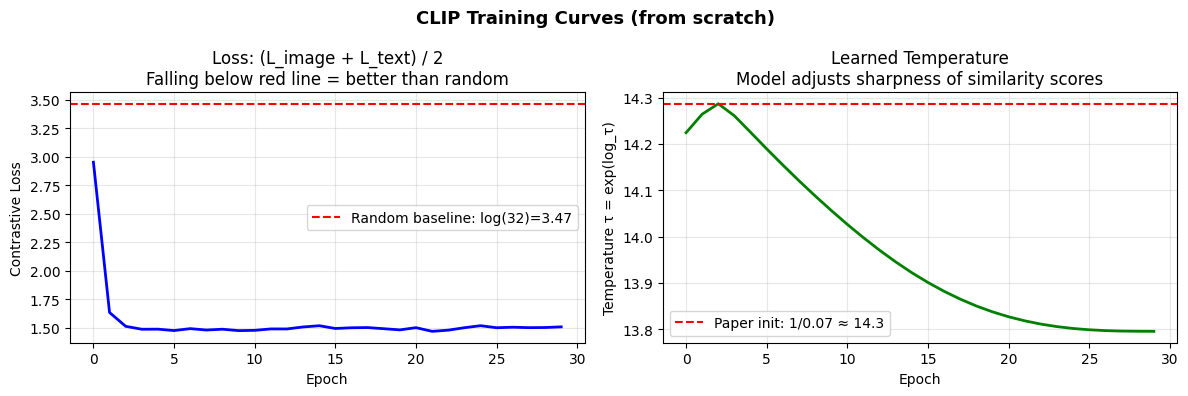

In [13]:
# ── Plot training curves ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CLIP Training Curves (from scratch)', fontsize=13, fontweight='bold')

ax1.plot(history['loss'], 'b-', linewidth=2)
ax1.axhline(y=math.log(BATCH_SIZE), color='red', linestyle='--',
            label=f'Random baseline: log({BATCH_SIZE})={math.log(BATCH_SIZE):.2f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Contrastive Loss')
ax1.set_title('Loss: (L_image + L_text) / 2\nFalling below red line = better than random')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['tau'], 'g-', linewidth=2)
ax2.axhline(y=1/0.07, color='red', linestyle='--',
            label=f'Paper init: 1/0.07 ≈ {1/0.07:.1f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Temperature τ = exp(log_τ)')
ax2.set_title('Learned Temperature\nModel adjusts sharpness of similarity scores')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clip_training.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 8: Zero-Shot Inference

## The zero-shot classification procedure (Algorithm 1 from Radford et al.)

1. For each of the $C$ classes, create a text prompt: *"a photo of a {class}"*
2. Encode all $C$ prompts with the text encoder → $C$ text embeddings
3. For a query image, encode it with the image encoder → 1 image embedding
4. Compute cosine similarity between image embedding and all $C$ text embeddings
5. Argmax → predicted class

No training on the test classes. No fine-tuning. Pure zero-shot.

In [ ]:
# ── Zero-Shot Inference ────────────────────────────────────────────────────
model.eval()

n_classes = len(CIFAR10_CLASSES)

# Step 1: Pre-compute text embeddings for all class prompts
class_texts = [desc for desc, _ in dataset.CLASSES]
class_tokens, class_eos = tokeniser.encode_batch(class_texts)
class_tokens = class_tokens.to(DEVICE)
class_eos    = class_eos.to(DEVICE)

with torch.no_grad():
    text_embeds = model.encode_text(class_tokens, class_eos)  # (n_classes, d_embed)

# Step 2: Evaluate on the CIFAR-10 test set, in batches
eval_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

correct = 0
total   = 0

with torch.no_grad():
    for images, _, _, labels in eval_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Step 3: Encode query images
        img_embeds = model.encode_image(images)              # (b, d_embed)

        # Step 4: Cosine similarity with all class text embeddings
        sims = img_embeds @ text_embeds.T                    # (b, n_classes)

        # Step 5: Predict
        preds = sims.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

accuracy = correct / total * 100
print(f'Zero-Shot Accuracy: {accuracy:.1f}%  ({correct}/{total})')
print(f'Random baseline   : {100/n_classes:.1f}%  ({n_classes} classes)')
print(f'Improvement over random: +{accuracy - 100/n_classes:.1f}%')


In [ ]:
# ── Visualise similarity matrix after training ─────────────────────────────
model.eval()

n_classes = len(CIFAR10_CLASSES)
short_labels = CIFAR10_CLASSES

# Grab one example image per class from the test set
example_images = {}
for img, _, _, label in test_dataset:
    if label not in example_images:
        example_images[label] = img
    if len(example_images) == n_classes:
        break

test_images_t = torch.stack([example_images[c] for c in range(n_classes)]).to(DEVICE)

with torch.no_grad():
    img_embeds = model.encode_image(test_images_t)                    # (n_classes, d_embed)
    tau = model.log_tau.exp()
    sim_matrix = (img_embeds @ text_embeds.T * tau).cpu().numpy()     # (n_classes, n_classes)
    sim_matrix_soft = np.exp(sim_matrix) / np.exp(sim_matrix).sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('CLIP Similarity Matrix After Training on CIFAR-10\n'
             'Diagonal should be bright (correct pairs)',
             fontsize=13, fontweight='bold')

# Raw logits
ax = axes[0]
im = ax.imshow(sim_matrix, cmap='Blues')
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels([f'Text:\n{l}' for l in short_labels], fontsize=7, rotation=45, ha='right')
ax.set_yticklabels([f'Image:\n{l}' for l in short_labels], fontsize=7)
ax.set_title('Similarity Logits S = I_f @ T_f.T * tau')
plt.colorbar(im, ax=ax)
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, f'{sim_matrix[i,j]:.1f}',
                ha='center', va='center', fontsize=6,
                color='white' if sim_matrix[i,j] > sim_matrix.max()*0.7 else 'black')

# Softmax probabilities
ax = axes[1]
im2 = ax.imshow(sim_matrix_soft, cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels([f'Text:\n{l}' for l in short_labels], fontsize=7, rotation=45, ha='right')
ax.set_yticklabels([f'Image:\n{l}' for l in short_labels], fontsize=7)
ax.set_title('After Softmax (probabilities)\nBright diagonal = model learned correctly')
plt.colorbar(im2, ax=ax)
for i in range(n_classes):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                               fill=False, edgecolor='red', linewidth=2))
    for j in range(n_classes):
        ax.text(j, i, f'{sim_matrix_soft[i,j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if sim_matrix_soft[i,j] > 0.5 else 'black')

plt.tight_layout()
plt.savefig('clip_similarity_after.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── t-SNE of learned embedding space ──────────────────────────────────────
model.eval()

n_classes = len(CIFAR10_CLASSES)
short_labels = CIFAR10_CLASSES

TSNE_N_SAMPLES = min(300, len(test_dataset))
tsne_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

all_img_embeds = []
all_class_ids  = []
seen = 0
with torch.no_grad():
    for images, _, _, labels in tsne_loader:
        images = images.to(DEVICE)
        ie = model.encode_image(images).cpu().numpy()
        all_img_embeds.append(ie)
        all_class_ids.append(labels.numpy())
        seen += images.shape[0]
        if seen >= TSNE_N_SAMPLES:
            break

img_emb_np = np.concatenate(all_img_embeds, axis=0)[:TSNE_N_SAMPLES]
all_labels  = np.concatenate(all_class_ids, axis=0)[:TSNE_N_SAMPLES]
txt_emb_np  = text_embeds.cpu().numpy()   # (n_classes, d_embed)

# Stack for t-SNE
combined = np.vstack([img_emb_np, txt_emb_np])
tsne     = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d   = tsne.fit_transform(combined)

img_2d = emb_2d[:len(img_emb_np)]
txt_2d = emb_2d[len(img_emb_np):]

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for cls in range(n_classes):
    mask = all_labels == cls
    ax.scatter(img_2d[mask, 0], img_2d[mask, 1],
               color=colors[cls], alpha=0.6, s=30, marker='o',
               label=f'Img: {short_labels[cls]}')
    # Text embedding as star
    ax.scatter(txt_2d[cls, 0], txt_2d[cls, 1],
               color=colors[cls], s=300, marker='*',
               edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(short_labels[cls], txt_2d[cls],
                fontsize=8, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

ax.set_title('t-SNE of CLIP Embedding Space (Trained on CIFAR-10)\n'
             'Circles=image embeddings, Stars=text embeddings\n'
             'Same colour = same class. Stars should be near their circles.',
             fontsize=11)
ax.axis('off')

# Legend for markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='gray', label='Image embedding', markersize=8),
    Line2D([0],[0], marker='*', color='gray', label='Text embedding',  markersize=12)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('clip_tsne_scratch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Stars (text) should cluster near their corresponding circles (images).')
print('This is the CLIP embedding space — shared image-text representation.')


---
# Section 9: Summary — Every Equation from Radford et al. Implemented

| Paper Component | Where Implemented | Equation |
|----------------|------------------|----------|
| Image encoder (ViT) | `VisionTransformer` | Patch embed → CLS → Transformer → project |
| Text encoder | `TextTransformer` | Token embed → pos embed → causal Transformer → EOS → project |
| Scaled dot-product attention | `MultiHeadSelfAttention` | $\text{softmax}(QK^T / \sqrt{d_k})V$ |
| Causal mask | `TextTransformer.causal_mask` | Upper triangular block |
| Shared embedding | Both encoders' `proj` layer | $\mathbb{R}^{d_\text{model}} \to \mathbb{R}^{d_e}$ |
| L2 normalisation | Both encoders' `forward` | `F.normalize(x, dim=-1)` |
| Temperature | `CLIP.log_tau` | $\tau = \exp(t)$, learned |
| Similarity matrix | `CLIP.forward` | $S = I_f \cdot T_f^T \cdot \tau$ |
| Contrastive loss | `clip_contrastive_loss` | $(L_I + L_T) / 2$ |
| Symmetric labels | `clip_contrastive_loss` | `labels = arange(B)` |
| Zero-shot inference | Section 8 | Argmax cosine similarity |
| Gradient clipping | Training loop | `clip_grad_norm_(..., 1.0)` |
| AdamW + cosine LR | Training loop | Per paper's training recipe |